# Figure 3.3-5 &mdash; the interaction energy between two molecules

Figure 3.3-5 in the text shows the *shape* of the interaction energy between a pair of
simple molecules: a steep repulsion at close range, a shallow attractive well, and
nothing at all at large separations. In this notebook you compute that curve for two
real molecules, **argon and methane**, with numbers on both axes. Once the axes have
units you can answer questions the sketch cannot:

- How far apart are two molecules in a gas? In a liquid?
- How strong is the attraction, compared with the thermal energy that pulls
  the pair apart?
- Where does the heat of vaporization come from, and how big should it be?

The model is the **Lennard-Jones 12-6 potential**. Thermodynamics does not derive it
&mdash; as Sec. 3.3 says, connecting molecular interactions to properties is the work of
statistical mechanics &mdash; but it is the standard form, it has only two parameters,
and both have been measured for these molecules.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
July 2026

## The Lennard-Jones 12-6 potential

$$ u(r) = 4\varepsilon\left[\left(\frac{\sigma}{r}\right)^{12}
        - \left(\frac{\sigma}{r}\right)^{6}\right] $$

Two parameters set the two scales:

| | | |
|---|---|---|
| $\sigma$ | a **distance** | the separation at which $u = 0$; roughly the molecular diameter |
| $\varepsilon$ | an **energy** | the depth of the attractive well |

The $r^{-12}$ term is the steep repulsion you feel once two electron clouds start to
overlap. The $r^{-6}$ term is the London attraction, which is the correct long-range
form for non-polar molecules. Setting $du/dr = 0$ locates the bottom of the well:

$$ r_{\min} = 2^{1/6}\,\sigma \approx 1.122\,\sigma,
   \qquad u(r_{\min}) = -\varepsilon $$

So $\sigma$ and $\varepsilon$ are all you need. Values for both molecules are set in the
next cell.

In [35]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when the property data is already alongside this notebook (the normal
# case: you cloned the repository and are running from code/ch3/). In Colab
# there is no repository, so fetch the data directory.
import os, sys
if not (os.path.isdir('../data') or os.path.isdir('data')):
    # rm -rf first: git clone REFUSES an existing directory, and under `!` that
    # failure is silent -- a half-finished earlier clone would otherwise leave an
    # empty thermo/ and surface as a baffling ImportError further down.
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/data .
DATA = '../data' if os.path.isdir('../data') else 'data'
# ---------------------------------------------------------------------------

In [36]:
"""
Figure 3.3-5: the Lennard-Jones interaction energy of a molecular pair.
u_LJ    : interaction energy at separation r
spacing : mean center-to-center spacing from a molar volume
kT_J21  : thermal energy at temperature T, in the same units as the energy axis
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import constants

R = constants.R        # gas constant, J/(mol K)
NA = constants.N_A     # Avogadro constant, 1/mol
kB = constants.k       # Boltzmann constant, J/K

# u(r) is the energy of a PAIR of molecules, so it is quoted in joules per pair.
# The values are around 10^-21 J, so the figures are drawn in units of 10^-21 J
# and the axis carries that factor rather than a scientific-notation offset.
J21 = 1e21             # (10^-21 J) per J
T_REF = 298.15         # K -- room temperature, for the kT column in the table
T_B_ARGON = 87.3       # K -- argon's normal boiling point (Appendix A.II)

# Lennard-Jones parameters fitted to second-virial-coefficient data
# (Hirschfelder, Curtiss and Bird, "Molecular Theory of Gases and Liquids",
# Wiley, 1954, Table I-A). sigma in nm, eps/k in K.
LJ = {
    "argon":   {"sigma": 0.3405, "eps_over_k": 119.8, "ls": "-"},
    "methane": {"sigma": 0.3817, "eps_over_k": 148.2, "ls": "--"},
}

for p in LJ.values():
    p["eps_J21"] = p["eps_over_k"] * kB * J21        # 10^-21 J per pair (molecular)
    p["eps"] = p["eps_over_k"] * kB * NA / 1000.0    # kJ/mol            (molar)
    p["eps_kT"] = p["eps_over_k"] / T_REF            # kT at T_REF
    p["rmin"] = 2 ** (1 / 6) * p["sigma"]            # nm


def kT_J21(T):
    """Thermal energy kT at temperature T, in units of 10^-21 J."""
    return kB * T * J21


def u_LJ(r, sigma, eps):
    """Lennard-Jones 12-6 energy. r and sigma in nm; the result has the units of eps."""
    sr6 = (sigma / r) ** 6
    return 4 * eps * (sr6 ** 2 - sr6)


def spacing(V_molar):
    """Mean center-to-center spacing (nm) for molar volume V_molar (m^3/mol).

    A molar volume gives a number density n = NA/V; the typical distance between
    neighbors is then n^(-1/3). This is an estimate of the average spacing, not
    a lattice constant.
    """
    return (NA / V_molar) ** (-1 / 3) * 1e9

## The energy scale

$u(r)$ is the energy of a **pair of molecules**, so it is quoted in joules per pair. For
these two molecules the well depth is around $1.7$&ndash;$2.0 \times 10^{-21}$ J, which is
why the figures are drawn in units of $10^{-21}$ J.

A molecular energy in joules is an unfamiliar size, so it needs something to be compared
against. There are two useful references, and they are the same idea in different clothes.

- **The thermal energy $kT$**, where $k$ is Boltzmann's constant. Random thermal motion
  has about this much energy available to pull a pair of molecules apart, so a well deeper
  than $kT$ can hold a pair together and a shallower one cannot. At room temperature
  $kT = 4.1 \times 10^{-21}$ J, which is *larger* than either well &mdash; both substances
  are gases at 298 K. At argon's normal boiling point, 87.3 K,
  $kT = 1.2 \times 10^{-21}$ J, now *smaller* than the well, and argon condenses.
- **$\varepsilon/k$, in kelvin.** Dividing an energy by $k$ turns it into the temperature
  at which thermal energy becomes comparable to it, which is why interaction parameters
  are tabulated this way &mdash; and why the legend of the figure quotes
  $\varepsilon/k$ rather than $\varepsilon$. Argon's $\varepsilon/k = 119.8$ K says the
  same thing as the line above.

### From molecular to molar energy

Thermodynamics works with molar quantities, so to compare $\varepsilon$ with anything else
in the chapter &mdash; $\Delta_{\mathrm{vap}}\underline{H}$, $C_P$, $\underline{U}$ &mdash;
multiply by Avogadro's number:

$$ \varepsilon\ [\text{J per pair}] \times N_A = \varepsilon\ [\text{J mol}^{-1}],
   \qquad kT \times N_A = RT $$

So argon's $1.65 \times 10^{-21}$ J per pair is $0.996$ kJ mol$^{-1}$, and the thermal
energy $kT$ at room temperature becomes the familiar $RT = 2.48$ kJ mol$^{-1}$. The cell
below reports the well depth in all of these units and does the conversion.

In [37]:
scales = pd.DataFrame({
    name: {
        "sigma (nm)": p["sigma"],
        "r_min (nm)": p["rmin"],
        # --- molecular: the energy of one pair ---
        "eps (10^-21 J per pair)": p["eps_J21"],
        "eps/k (K)": p["eps_over_k"],
        "eps (kT at 298 K)": p["eps_kT"],
        "eps (eV per pair)": p["eps_over_k"] * kB / constants.e,
        # --- molar: the same energy times NA ---
        "eps (kJ/mol)": p["eps"],
    } for name, p in LJ.items()
}).T

print(scales.to_string(float_format=lambda x: f"{x:9.4f}"))

print(f"\nthermal energy for comparison:")
for T in (T_REF, T_B_ARGON):
    print(f"  kT at {T:6.2f} K = {kT_J21(T):.4f} x 10^-21 J per pair"
          f"  = {R * T / 1000:.3f} kJ/mol")
print(f"\nAvogadro conversion: 1 x 10^-21 J per pair"
      f" = {1e-21 * NA / 1000:.4f} kJ/mol")

         sigma (nm)  r_min (nm)  eps (10^-21 J per pair)  eps/k (K)  eps (kT at 298 K)  eps (eV per pair)  eps (kJ/mol)
argon        0.3405      0.3822                   1.6540   119.8000             0.4018             0.0103        0.9961
methane      0.3817      0.4284                   2.0461   148.2000             0.4971             0.0128        1.2322

thermal energy for comparison:
  kT at 298.15 K = 4.1164 x 10^-21 J per pair  = 2.479 kJ/mol
  kT at  87.30 K = 1.2053 x 10^-21 J per pair  = 0.726 kJ/mol

Avogadro conversion: 1 x 10^-21 J per pair = 0.6022 kJ/mol


## Figure 3.3-5

Argon is drawn solid and methane dashed rather than in two colors, so the figure reads
the same in black and white.

The first version below is the figure as it appears in the text, and it is the one written
to `pdf/Fig_3.3-5.pdf`. The second adds labels for $\sigma$, $\varepsilon$, and $r_{\min}$
on the argon curve, and a line at $u = -kT$ evaluated at argon's normal boiling point
&mdash; the depth a well has to reach before it can hold a pair of molecules together
against thermal motion. Both wells clear it, which is why both substances are liquids at
those temperatures.

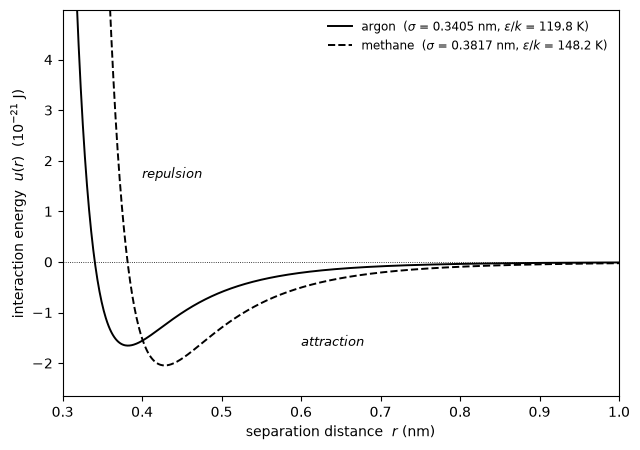

In [38]:
fig, ax = plt.subplots(figsize=(6.5, 4.6))
BLACK = "black"

r = np.linspace(0.30, 1.00, 800)

for name, p in LJ.items():
    ax.plot(r, u_LJ(r, p["sigma"], p["eps_J21"]), p["ls"], color=BLACK, lw=1.4,
            label=f"{name}  ($\\sigma$ = {p['sigma']:.4f} nm, "
                  f"$\\varepsilon/k$ = {p['eps_over_k']:.1f} K)")

ax.axhline(0.0, color=BLACK, lw=0.6, ls=":")

ax.text(0.4, 1.66, "repulsion", fontsize=9, style="italic")
ax.text(0.60, -1.66, "attraction", fontsize=9, style="italic")

ax.set_xlim(0.30, 1.00)
ax.set_ylim(-2.66, 4.98)
ax.set_xlabel("separation distance  $r$ (nm)")
ax.set_ylabel(r"interaction energy  $u(r)$  ($10^{-21}$ J)")
ax.legend(loc="upper right", fontsize=8.5, frameon=False)

fig.tight_layout()
os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/Fig_3.3-5.pdf")
plt.show()

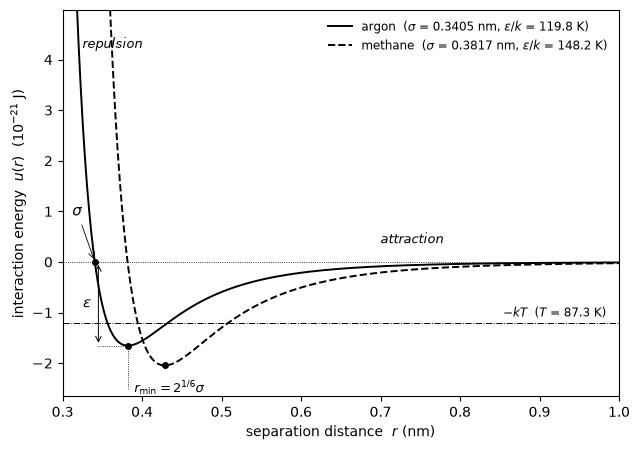

In [39]:
fig, ax = plt.subplots(figsize=(6.5, 4.6))
BLACK = "black"

r = np.linspace(0.30, 1.00, 800)

for name, p in LJ.items():
    ax.plot(r, u_LJ(r, p["sigma"], p["eps_J21"]), p["ls"], color=BLACK, lw=1.4,
            label=f"{name}  ($\\sigma$ = {p['sigma']:.4f} nm, "
                  f"$\\varepsilon/k$ = {p['eps_over_k']:.1f} K)")

ax.axhline(0.0, color=BLACK, lw=0.6, ls=":")

# the thermal energy at argon's boiling point: the depth a well must reach to
# hold a pair together. Both wells are deeper than this, and argon is a liquid
# at 87.3 K. (At 298 K, kT = 4.1 and would sit off the bottom of this frame.)
ax.axhline(-kT_J21(T_B_ARGON), color=BLACK, lw=0.7, ls="-.")
ax.text(0.985, -kT_J21(T_B_ARGON) + 0.07,
        f"$-kT$  ($T$ = {T_B_ARGON:.1f} K)", fontsize=8.5, ha="right", va="bottom")

# --- anatomy of the curve, marked on argon ---
ar = LJ["argon"]

# sigma: the separation where u = 0
ax.plot([ar["sigma"]], [0.0], "o", color=BLACK, ms=4)
ax.annotate(r"$\sigma$", xy=(ar["sigma"], 0.0), xytext=(ar["sigma"] - 0.022, 0.91),
            fontsize=11, ha="center",
            arrowprops=dict(arrowstyle="->", lw=0.6, color=BLACK))

# the well depth. The measuring arrow sits to the LEFT of the minimum, where
# neither curve runs, so it cannot be confused with the methane repulsive wall.
ax.plot([ar["rmin"]], [-ar["eps_J21"]], "o", color=BLACK, ms=4)
ax.plot([LJ["methane"]["rmin"]], [-LJ["methane"]["eps_J21"]], "o", color=BLACK, ms=4)
X_ARROW = 0.345
ax.plot([X_ARROW, ar["rmin"]], [-ar["eps_J21"]] * 2, ":", color=BLACK, lw=0.6)
ax.annotate("", xy=(X_ARROW, 0.0), xytext=(X_ARROW, -ar["eps_J21"]),
            arrowprops=dict(arrowstyle="<->", lw=0.7, color=BLACK))
ax.annotate(r"$\varepsilon$", xy=(X_ARROW - 0.008, -ar["eps_J21"] / 2),
            fontsize=11, va="center", ha="right")

# r_min, dropped to a label below the curve
ax.plot([ar["rmin"]] * 2, [-ar["eps_J21"], -2.52], ":", color=BLACK, lw=0.6)
ax.text(ar["rmin"] + 0.008, -2.49, r"$r_{\min} = 2^{1/6}\sigma$",
        fontsize=9, ha="left", va="center")

ax.text(0.325, 4.23, "repulsion", fontsize=9, style="italic")
ax.text(0.70, 0.37, "attraction", fontsize=9, style="italic")

ax.set_xlim(0.30, 1.00)
ax.set_ylim(-2.66, 4.98)
ax.set_xlabel("separation distance  $r$ (nm)")
ax.set_ylabel(r"interaction energy  $u(r)$  ($10^{-21}$ J)")
ax.legend(loc="upper right", fontsize=8.5, frameon=False)

fig.tight_layout()
plt.show()

## Where the gas and the liquid sit on the curve

The text argues that a dilute gas has essentially no interaction energy, that a liquid
sits near the bottom of the well, and that a solid sits nearer still &mdash; so internal
energy increases in the order solid, liquid, gas. You can check all of that.

All you need is a typical separation for each state, and a molar volume gives you one:
$r \approx (N_A/\underline{V})^{-1/3}$. The liquid densities come from the property
database that Appendix A.II is printed from (`code/data/pure_property.csv`), so nothing
here comes from outside the book.

In [40]:
props = pd.read_csv(f"{DATA}/pure_property.csv")
props["Name"] = props["Name"].str.strip()
props = props.set_index("Name")

rows = []
for name, p in LJ.items():
    d = props.loc[name]
    V_liq = d["Molwt"] / d["Lden"] * 1e-6          # m^3/mol, at T = Tden
    V_gas = R * 300.0 / 1e5                        # ideal gas, 1 bar and 300 K
    r_liq, r_gas = spacing(V_liq), spacing(V_gas)
    rows.append({
        "T_liq (K)": d["Tden"],
        "V_liq (cm3/mol)": V_liq * 1e6,
        "r_liq (nm)": r_liq,
        "r_liq / r_min": r_liq / p["rmin"],
        # energies as a fraction of the well depth: pass eps = 1, so these
        # numbers do not depend on which unit the energy axis uses
        "u(r_liq)/eps": u_LJ(r_liq, p["sigma"], 1.0),
        "r_gas (nm)": r_gas,
        "r_gas / sigma": r_gas / p["sigma"],
        "u(r_gas)/eps": u_LJ(r_gas, p["sigma"], 1.0),
    })

states = pd.DataFrame(rows, index=list(LJ))
print(states.to_string(float_format=lambda x: f"{x:10.4f}"))

         T_liq (K)  V_liq (cm3/mol)  r_liq (nm)  r_liq / r_min  u(r_liq)/eps  r_gas (nm)  r_gas / sigma  u(r_gas)/eps
argon      90.0000          29.0954      0.3642         0.9529       -0.8876      3.4599        10.1613       -0.0000
methane   112.0000          37.7482      0.3972         0.9272       -0.6702      3.4599         9.0645       -0.0000


Two columns carry the result. Both energies are reported as fractions of the well depth,
$u/\varepsilon$, so they do not depend on the units of the energy axis.

- **In the liquid, $r \approx 0.93$&ndash;$0.95\,r_{\min}$, and $u$ is between
  $-0.7\,\varepsilon$ and $-0.9\,\varepsilon$.** The molecules sit essentially at the
  bottom of the well, pushed just past the minimum by their neighbors.
- **In the gas at 1 bar, $r \approx 10\,\sigma$ and $u/\varepsilon \sim 10^{-6}$.** The
  interactions are not merely small, they are negligible to six figures. That is the real
  reason the ideal gas law works so well at ambient pressure &mdash; a much stronger
  statement than "the molecules are far apart."

A logarithmic distance axis puts both states in one frame.

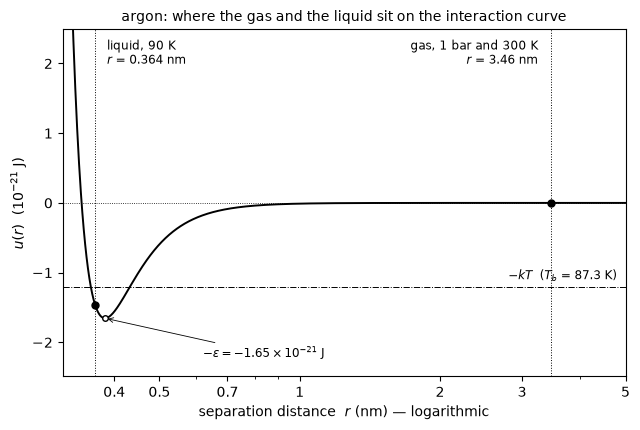

In [ ]:
ar = LJ["argon"]
d = props.loc["argon"]
r_liq = spacing(d["Molwt"] / d["Lden"] * 1e-6)
r_gas = spacing(R * 300.0 / 1e5)

fig, ax = plt.subplots(figsize=(6.5, 4.4))

r = np.logspace(np.log10(0.31), np.log10(5.0), 1200)
ax.semilogx(r, u_LJ(r, ar["sigma"], ar["eps_J21"]), "-", color=BLACK, lw=1.4)
ax.axhline(0.0, color=BLACK, lw=0.6, ls=":")

for r_state, label, ha, xoff in (
        (r_liq, f"liquid, {d['Tden']:.0f} K\n$r$ = {r_liq:.3f} nm", "left", 1.06),
        (r_gas, f"gas, 1 bar and 300 K\n$r$ = {r_gas:.2f} nm", "right", 0.94)):
    ax.axvline(r_state, color=BLACK, lw=0.7, ls=":")
    ax.plot([r_state], [u_LJ(r_state, ar["sigma"], ar["eps_J21"])], "o",
            color=BLACK, ms=5)
    ax.annotate(label, xy=(r_state * xoff, 2.36), fontsize=8.5, ha=ha, va="top")

# the thermal energy at the normal boiling point, for comparison with the well
ax.axhline(-kT_J21(d["Tb"]), color=BLACK, lw=0.7, ls="-.")
ax.text(4.8, -kT_J21(d["Tb"]) + 0.07,
        rf"$-kT$  ($T_b$ = {d['Tb']:.1f} K)", fontsize=8.5, ha="right", va="bottom")

ax.plot([ar["rmin"]], [-ar["eps_J21"]], "o", color=BLACK, ms=4, mfc="white")
ax.annotate(rf"$-\varepsilon = -{ar['eps_J21']:.2f} \times 10^{{-21}}$ J",
            xy=(ar["rmin"], -ar["eps_J21"]), xytext=(0.62, -2.16), fontsize=8.5,
            ha="left", va="center",
            arrowprops=dict(arrowstyle="->", lw=0.6, color=BLACK))

ax.set_xlim(0.31, 5.0)
ax.set_ylim(-2.49, 2.49)
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xticks([0.4, 0.5, 0.7, 1.0, 2.0, 3.0, 5.0])
ax.set_xticklabels(["0.4", "0.5", "0.7", "1", "2", "3", "5"])
ax.set_xlabel("separation distance  $r$ (nm) — logarithmic")
ax.set_ylabel(r"$u(r)$  ($10^{-21}$ J)")
ax.set_title("argon: where the gas and the liquid sit on the interaction curve",
             fontsize=10)

fig.tight_layout()
plt.show()

## The well depth and the heat of vaporization

The text says that *"the energy that must be added to a liquid to cause its molecules to
move farther apart and vaporize is the heat of vaporization
$\Delta_{\mathrm{vap}}\underline{H}$."* If that is what
$\Delta_{\mathrm{vap}}\underline{H}$ is, it should come out to a small multiple of
$\varepsilon$: about $z/2$ times the well depth, where $z$ is the number of near
neighbors a molecule loses when it evaporates. The factor of two is there because each
pair would otherwise be counted twice.

Note that $\Delta_{\mathrm{vap}}\underline{H}$ is a **molar** quantity and $\varepsilon$
is a molecular one, so this is a comparison you cannot make without the $N_A$ conversion
from the calculation block above.

You can test the claim without any data the book does not already print. Appendix A.II
carries Wagner vapor-pressure constants for both species (the `Eq = 1` form),

$$ \ln\frac{P^{\mathrm{vap}}}{P_c}
   = \frac{a\tau + b\tau^{1.5} + c\tau^{3} + d\tau^{6}}{T_r},
   \qquad \tau = 1 - T_r $$

and the Clausius-Clapeyron equation turns its slope into a heat of vaporization,

$$ \Delta_{\mathrm{vap}}\underline{H}
   \approx R T^2 \frac{d \ln P^{\mathrm{vap}}}{dT} $$

which assumes an ideal vapor and neglects the liquid molar volume &mdash; good to a few
per cent at 1 atm.

**Check the correlation before you use it.** At the normal boiling point the Wagner
equation has to return 1 atm. If it does, you are reading the constants correctly; if it
does not, nothing computed from them is reliable.

In [42]:
ATM = 1.01325   # bar


def ln_Pr_wagner(Tr, a, b, c, dd):
    """ln(Pvap/Pc) from the Wagner constants (Appendix A.II, Eq = 1 form)."""
    tau = 1 - Tr
    return (a * tau + b * tau ** 1.5 + c * tau ** 3 + dd * tau ** 6) / Tr


def Pvap_bar(T, d):
    coef = [d["VpA"], d["VpB"], d["VpC"], d["VpD"]]
    return d["Pc"] * np.exp(ln_Pr_wagner(T / d["Tc"], *coef))


def dHvap(T, d, h=0.01):
    """Clausius-Clapeyron heat of vaporization (kJ/mol) from the slope of ln Pvap."""
    dlnP_dT = (np.log(Pvap_bar(T + h, d)) - np.log(Pvap_bar(T - h, d))) / (2 * h)
    return R * T ** 2 * dlnP_dT / 1000.0


for name, p in LJ.items():
    d = props.loc[name]
    Tb = d["Tb"]
    P_check = Pvap_bar(Tb, d)
    dH = dHvap(Tb, d)
    print(f"{name:8s}  Tb = {Tb:6.1f} K   Pvap(Tb) = {P_check:.4f} bar "
          f"(should be {ATM:.4f}, off by {100*(P_check/ATM - 1):+.1f}%)")
    print(f"{'':8s}  dHvap = {dH:5.2f} kJ/mol   eps = {p['eps']:.3f} kJ/mol   "
          f"dHvap/eps = {dH/p['eps']:.1f}   ->  z = {2*dH/p['eps']:.0f}")
    print(f"{'':8s}  the same well, in units of kT at Tb: "
          f"eps/kTb = {p['eps_over_k']/Tb:.2f} kT\n")

argon     Tb =   87.3 K   Pvap(Tb) = 1.0074 bar (should be 1.0132, off by -0.6%)
          dHvap =  6.70 kJ/mol   eps = 0.996 kJ/mol   dHvap/eps = 6.7   ->  z = 13
          the same well, in units of kT at Tb: eps/kTb = 1.37 kT

methane   Tb =  111.6 K   Pvap(Tb) = 0.9858 bar (should be 1.0132, off by -2.7%)
          dHvap =  8.62 kJ/mol   eps = 1.232 kJ/mol   dHvap/eps = 7.0   ->  z = 14
          the same well, in units of kT at Tb: eps/kTb = 1.33 kT



Both species give $\Delta_{\mathrm{vap}}\underline{H} \approx 7\varepsilon$, so
$z \approx 13$&ndash;$14$ near neighbors &mdash; close to the 12 you would get from a
close-packed arrangement of spheres, which is about right for a liquid of nearly spherical
molecules. The figure and the measured heat of vaporization tell a consistent story, and
the well depth is a real energy rather than a cartoon.

Read the last line of output on its own. At the normal boiling point the well
is about 1.4 times $kT$ for argon and 1.3 times for methane, where at room temperature it
was only 0.4 to 0.5 times. Condensation happens when the attraction between a pair becomes
just a little stronger than the thermal energy pulling them apart.

Two caveats on these numbers.

- The vapor-pressure slope reproduces the tabulated heats of vaporization
  (6.43 kJ mol$^{-1}$ for argon, 8.17 for methane) to about 5%. The error is in the
  ideal-vapor assumption behind Clausius-Clapeyron, not in the correlation.
- $\varepsilon$ and $\sigma$ are **fitted** parameters, not measured lengths and energies,
  and their values depend on which data were fitted. The set used here comes from second
  virial coefficients. Parameters fitted to *viscosity* data give $\sigma = 0.3542$ nm and
  $\varepsilon/k = 93.3$ K for argon &mdash; a 20% shallower well, from the same model and
  the same molecule. A model form plus a data set gives you parameters; the parameters are
  not a property of the molecule alone, and reporting where they came from is part of the
  answer.

## Things to try

1. Move the thermal-energy line from `T_B_ARGON` to `T_REF` (298 K). It drops off the
   bottom of the frame, because at room temperature $kT$ is more than twice either well
   depth. That is another way of seeing why argon and methane are gases here.
2. Swap in the viscosity-fitted parameters quoted above and see how far
   $\Delta_{\mathrm{vap}}\underline{H}/\varepsilon$ moves. Which fit gives the more
   physical $z$?
3. Add a third molecule from `pure_property.csv`. Krypton and xenon are nearly ideal
   Lennard-Jones fluids; carbon dioxide is not spherical, so expect it to fit less well.
4. Plot the **force** between the pair, $-du/dr$, and find the separation of strongest
   attraction. It is not at $r_{\min}$ &mdash; why not?
5. Find the separation at which $u = -kT$ at 298 K, and compare it with the mean spacing in
   a gas at 1 bar. What does that comparison tell you about the size of the correction the
   ideal gas law needs?
6. Replace the $r^{-12}$ repulsion with $r^{-9}$, holding $\varepsilon$ and the position of
   the minimum fixed. How much does the shape of the well change? That is the sense in
   which the "12" is a convenience rather than physics.